### Loading the MASTER dataset

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('data/master_migration_dataset.csv')

In [16]:
df.head(5)

,country,date,fertility_rate,gdp_per_capita,gdp_growth_rate,population,unemployment_rate,net_migration,avg_dest_gdp,gdp_gap_ratio,migration_pressure,pop_growth,gdp_lag_5,fertility_lag_3
0,Afghanistan,2000,7.566,174.930991,-9.431974,20130327.0,7.897,-1025973.0,27050.256836,154.633874,1169.959888,NaN,NaN,NaN
1,Afghanistan,2001,7.453,138.706822,-9.431974,20284307.0,7.973,-212872.0,27035.950254,194.914352,1452.696665,0.764916,NaN,NaN
2,Afghanistan,2002,7.320,178.954088,28.600001,21378117.0,7.867,860349.0,28408.729515,158.748703,1162.040510,5.392395,NaN,NaN
3,Afghanistan,2003,7.174,198.871116,8.832278,22733049.0,7.844,247317.0,32507.907324,163.462186,1172.677723,6.337939,NaN,7.566
4,Afghanistan,2004,7.018,221.763654,1.414118,23560654.0,7.794,-269194.0,36517.249768,164.667425,1155.635986,3.640537,NaN,7.453


In [17]:
print("\nCountries:", df['country'].nunique())


Countries: 34


#### Deep EDA on target variable

In [26]:
# Focusing on destination countries only

destination_countries = ['United Kingdom', 'United States', 'Germany', 'Canada', 'France']

In [27]:
destination_df = df[df['country'].isin(destination_countries)].copy()

In [28]:
destination_df

,country,date,fertility_rate,gdp_per_capita,gdp_growth_rate,population,unemployment_rate,net_migration,avg_dest_gdp,gdp_gap_ratio,migration_pressure,pop_growth,gdp_lag_5,fertility_lag_3
120,Canada,2000,1.5100,24271.002056,5.138539,30685730.0,6.829,201727.0,27050.256836,1.114509,1.682909,NaN,NaN,NaN
121,Canada,2001,1.5400,23822.096211,1.875098,31020855.0,7.219,222100.0,27035.950254,1.134911,1.747762,1.092120,NaN,NaN
122,Canada,2002,1.5200,24256.019234,2.999255,31359199.0,7.665,208060.0,28408.729515,1.171203,1.780229,1.090698,NaN,NaN
123,Canada,2003,1.5500,28301.864594,1.806385,31642461.0,7.574,185643.0,32507.907324,1.148614,1.780351,0.903282,NaN,1.5100
124,Canada,2004,1.5600,32145.541262,3.092364,31938807.0,7.185,194611.0,36517.249768,1.135997,1.772156,0.936545,NaN,1.5400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,United States,2019,1.7060,64746.450678,2.583825,330226227.0,3.669,1774500.0,48464.509149,0.748528,1.276988,0.516438,54973.420752,1.8205
812,United States,2020,1.6415,63515.949181,-2.163029,331577720.0,8.055,329769.0,46886.240399,0.738181,1.211723,0.409263,56572.918900,1.7655
813,United States,2021,1.6640,70205.050916,6.055053,332099760.0,5.349,674787.0,53371.487077,0.760223,1.265011,0.157441,57638.101837,1.7295
814,United States,2022,1.6565,76657.248884,2.512375,334017321.0,3.650,1319009.0,54293.250089,0.708260,1.173232,0.577405,59635.098440,1.7060


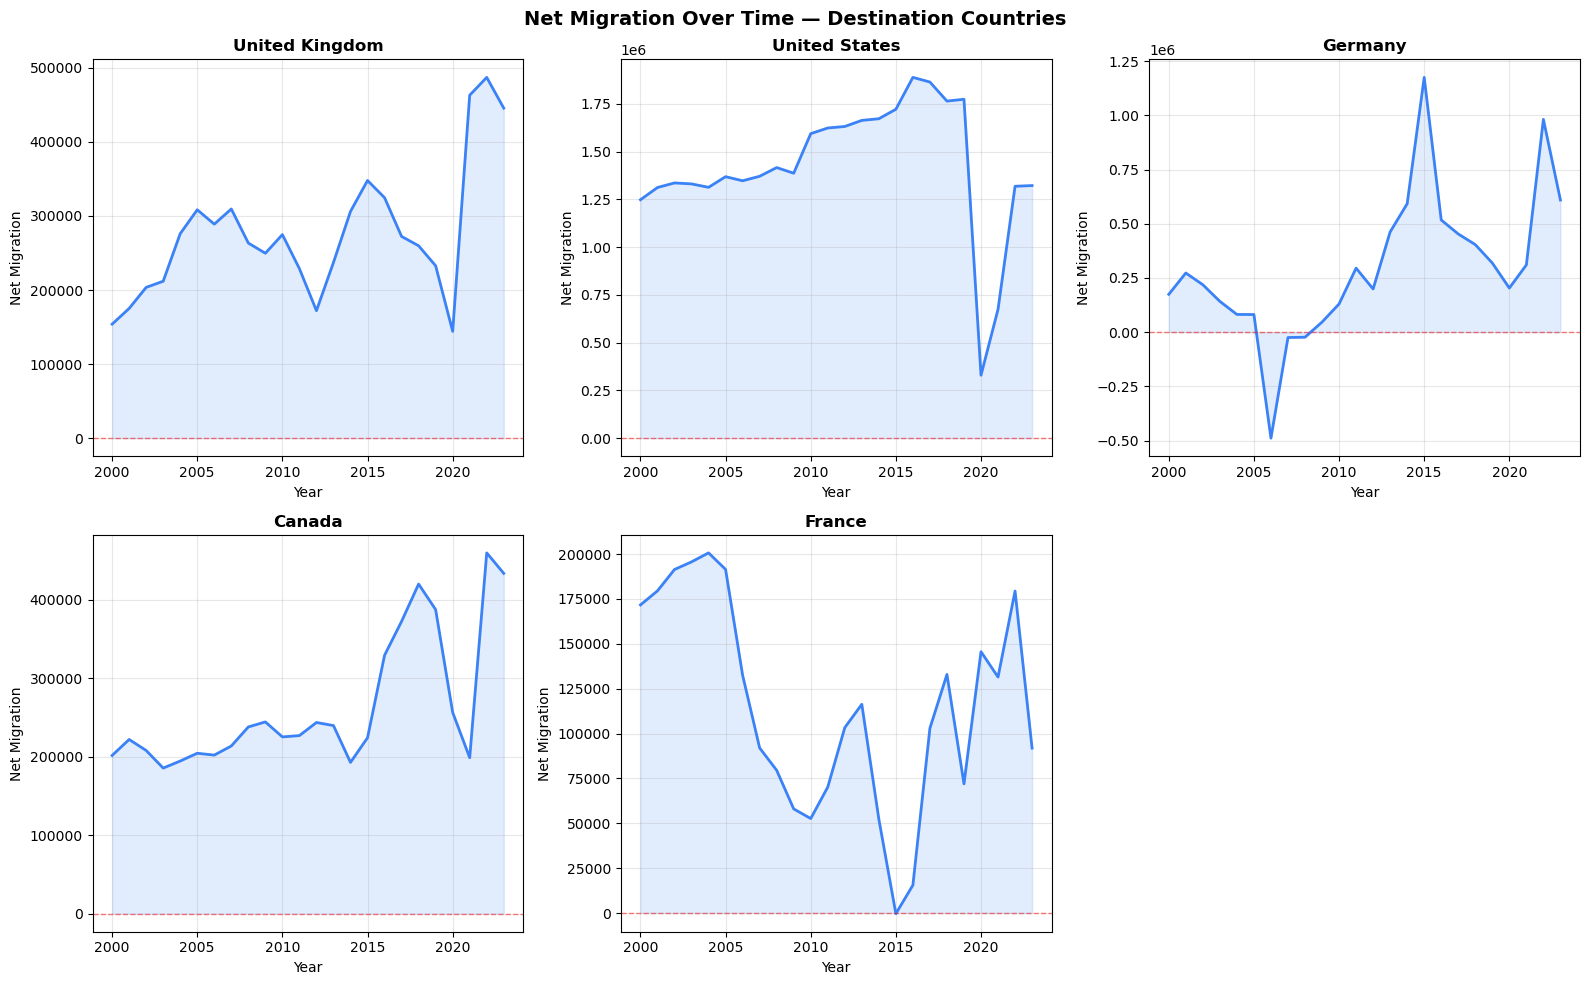

In [29]:
# ── Plot net migration over time for each destination ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, country in enumerate(destination_countries):
    data = destination_df[destination_df['country'] == country]
    axes[i].plot(data['date'], data['net_migration'],
                 color='#3b82f6', linewidth=2)
    axes[i].axhline(0, color='red', linestyle='--',
                    linewidth=1, alpha=0.5)
    axes[i].fill_between(data['date'], data['net_migration'],
                         0, alpha=0.15, color='#3b82f6')
    axes[i].set_title(country, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Net Migration')
    axes[i].grid(alpha=0.3)

axes[5].axis('off')
plt.suptitle('Net Migration Over Time — Destination Countries',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/net_migration_destinations.png', dpi=150)
plt.show()

#### Correlation analysis

In [30]:
# ── Select only numerical columns ──
num_cols = ['fertility_rate', 'gdp_per_capita', 'gdp_growth_rate',
            'population', 'unemployment_rate', 'net_migration',
            'gdp_gap_ratio', 'migration_pressure',
            'pop_growth', 'gdp_lag_5', 'fertility_lag_3']

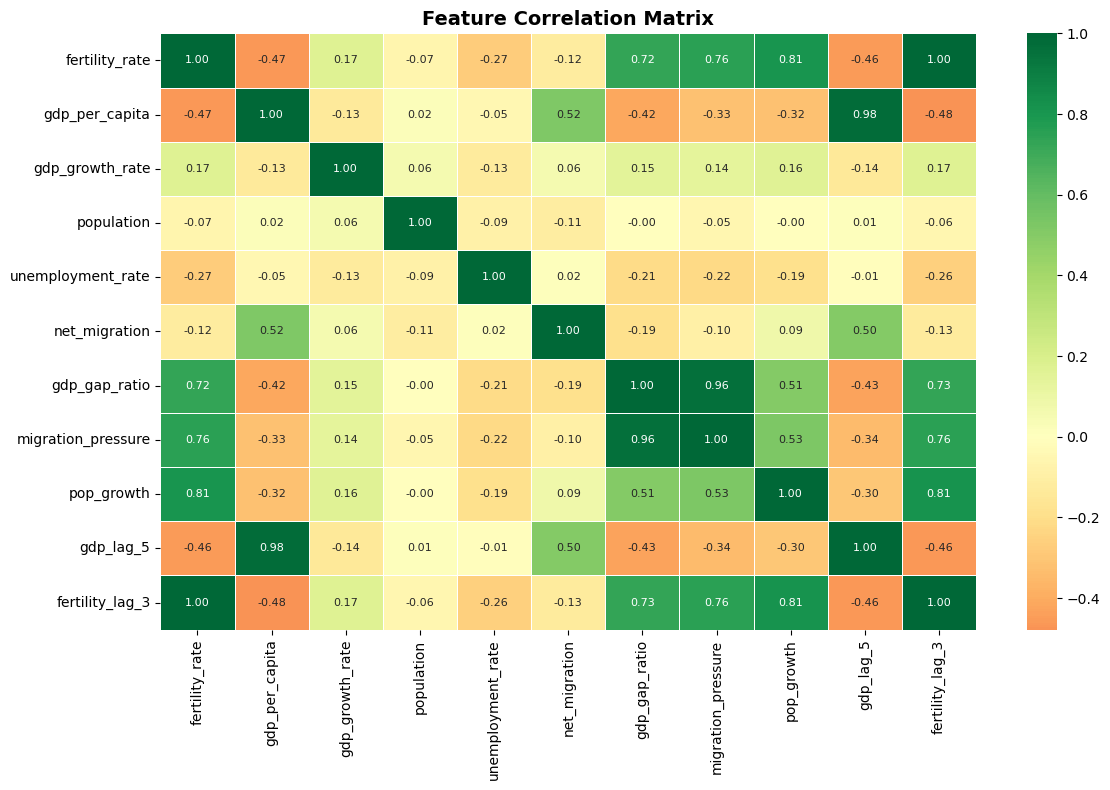


Correlation with net_migration:
net_migration         1.000
gdp_per_capita        0.518
gdp_lag_5             0.505
pop_growth            0.087
gdp_growth_rate       0.058
unemployment_rate     0.015
migration_pressure   -0.102
population           -0.113
fertility_rate       -0.122
fertility_lag_3      -0.131
gdp_gap_ratio        -0.189
Name: net_migration, dtype: float64


In [32]:
# ── Correlation matrix ──
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/correlation_matrix.png', dpi=150)
plt.show()

# ── Correlation with net_migration specifically ──
print("\nCorrelation with net_migration:")
print(corr['net_migration'].sort_values(ascending=False).round(3))